##### <h1 style="text-align:center"> Drexel University </h1>
<h2 style = "text-align:center"> College of Computing and Informatics</h2>
<h2 style = "text-align:center">DSCI 631: Applied Machine Learning</h2>
<h3 style = "text-align:center">Assignment 3</h3>
<h4> </h4>


<h3 style="color:red; font-weight:bold; text-decoration: underline">DON'T FORGET TO PUT YOUR TEAM MEMBERS' NAMES BELOW</h3
                                                                                                                          
### TEAM MEMBERS: Manyu Ghildiyal and Silas McAllister-Spooner

### A. Assignment Overview
This assignment provides the opportunity for you to practice with various skills in unsupervised learning, and convolution neural network

### B. What to Hand In

Sumbit a completed this Jupyter notebook.

### C. How to Hand In

Submit your Jupyter notebook file through the course website in the Blackboard Learn system.

### D. When to Hand In

1. Submit your assignment no later than 11:59 pm in the due date.
2. There will be a 10% (absolute value) deduction for each day of lateness, to a maximum of 3 days; assignments will not be accepted beyond that point. Missing work will earn a zero grade.

### E. Written Presentation Requirements (if applicable)
Images must be clear and legible. Assignments will be judged on the basis of visual appearance, grammatical correctness, and quality of writing, as well as their contents. Please make sure that the text of your assignments is well-structured, using paragraphs, full sentences, and other features of well-written presentation.

### F. Academic Honesty

Each student is required to submit the Academic Honesty Form at the beginning of the term to cover all the deliverables (for example: assignments, projects, quizzes). Each piece of work must be original. That means, individual quizzes must be done individually without discussing and collaborating with anybody else. Team assignments must be written and programmed by your own team members. No team should copy any piece of work from other teams. The Drexel University Academic Honesty Rules and Procedures (as stated in the student handbook) will be adhered to strictly.  

### G. Marking Schemes:

Marking assignments will be based on several aspects: presentation, correctness and coding styles.

For programming questions, 10% of the mark will be judged on the coding style.

The following is a set of guidelines for the coding style in this course:
1. Write a good comment.
2. Use appropriate indentations to indicate control flows and blocks of code.
3. When breaking up a long line, break it before an operator, not after.

### H. Answer the following questions:
**Your answer should be combined with code and brief text answer.** Please ensure that your Jupyter notebook does not have too much spurious output. If you like, you can share your notebook in progress with me on Kaggle: leiwangv (lw474@drexel.edu)

### Data for part 1 in this assignment:
* URL: https://www.kaggle.com/datasets/abdelazizsami/cdc-diabetes-health-indicators?select=diabetes_binary_health_indicators_BRFSS2015.csv [only dataset to look into: diabetes_binary_health_indicators_BRFSS2015.csv]

* In this assignment, you should work without the ground truth labels as much as possible. Often inspecting and visualizing the data is the only way to understand the result of clustering and outlier detection.
* For Questions 1-2 visualization, you should look at the plots before making use of the ground truth labels first, then use the ground truth labels (`Diabetes_binary`) to color the points in your plots.

#### Question 1-1:
Create plots to visualize the distribution of all features (both jointly and for each class). Describe your observation.

Then visualize the data using PCA (top two principal components). Make another plot of explained variance (%) in PCA. Discuss what would be a good threshold for the number of principal components if you wanted to reduce the dimensionality of the data?

In [1]:
#Import Statements
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

In [2]:
diabetes_file = pd.read_csv('diabetes_binary_health_indicators_BRFSS2015.csv')
#Just to check it actaully works
diabetes_file.head()

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


##### Feature Distribution - Class

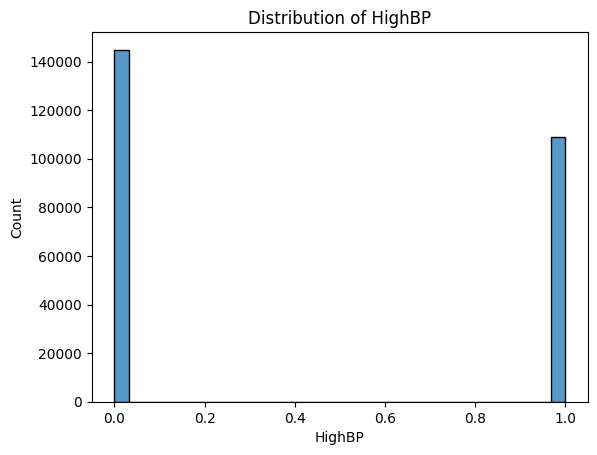

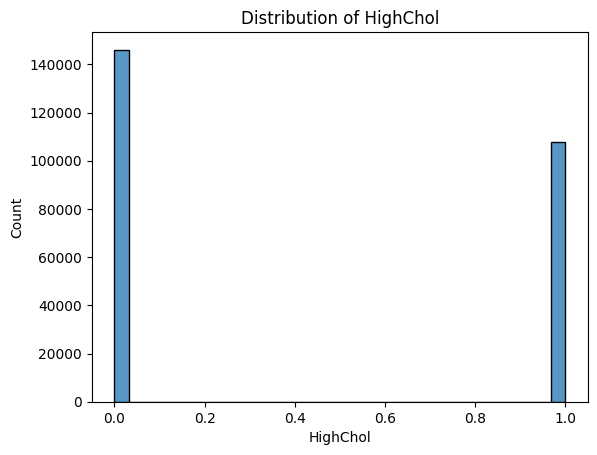

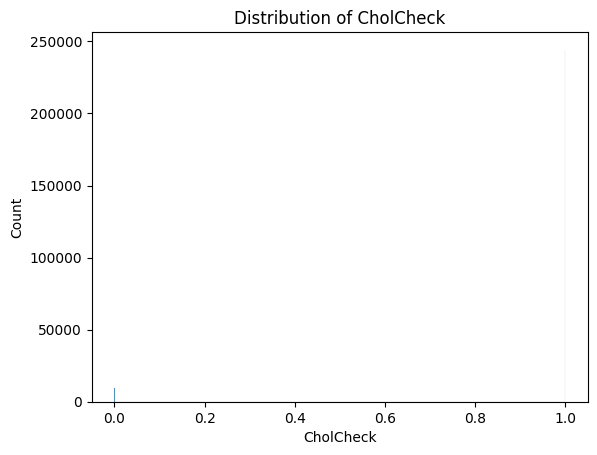

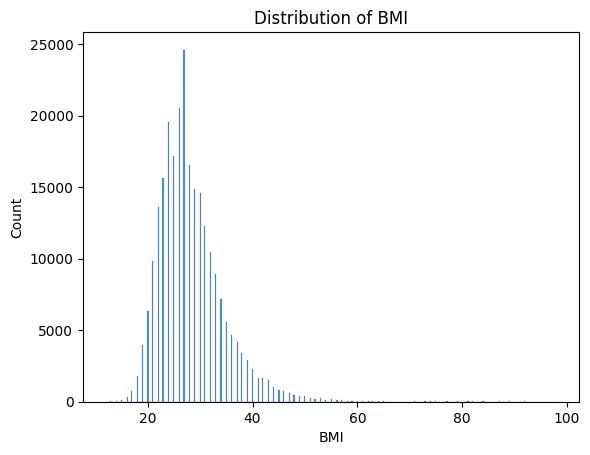

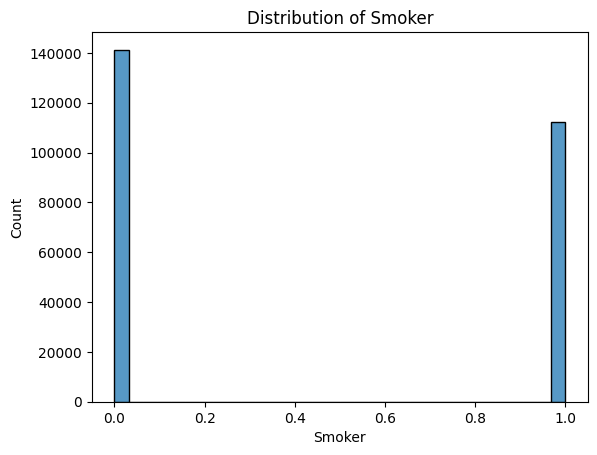

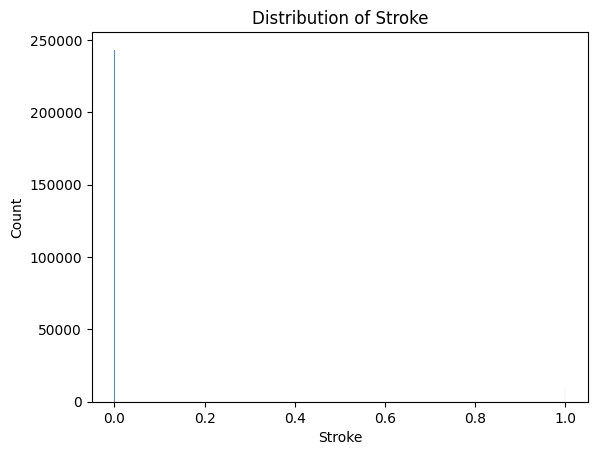

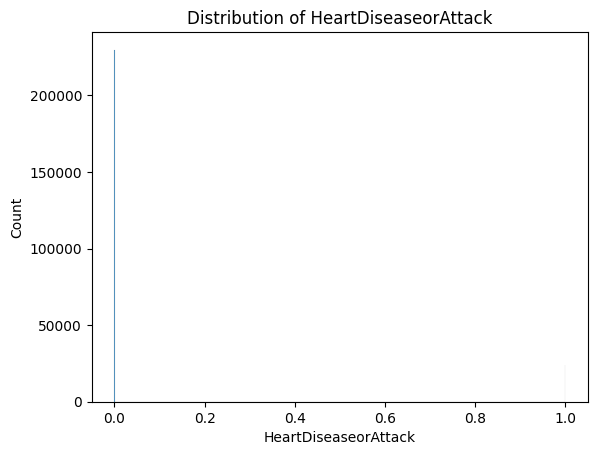

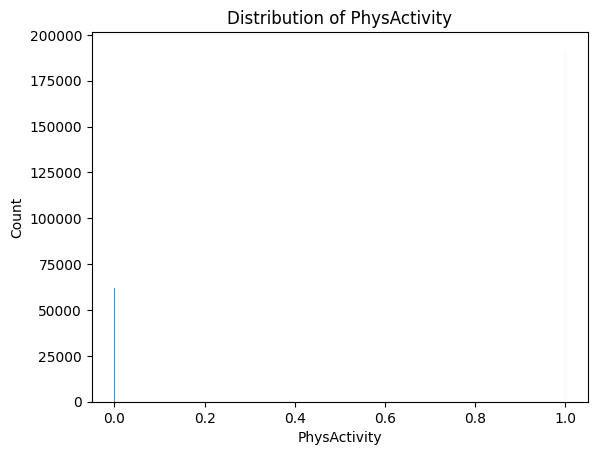

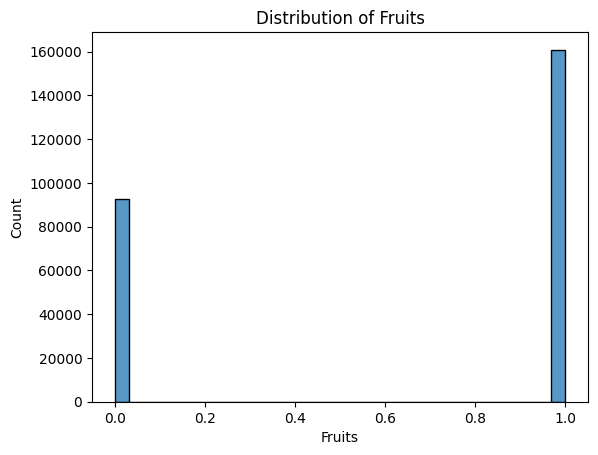

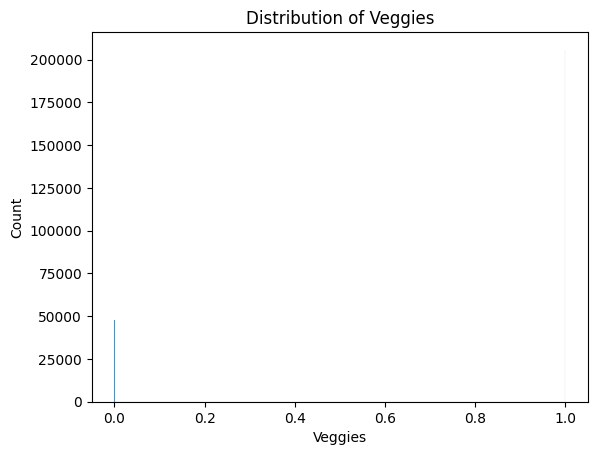

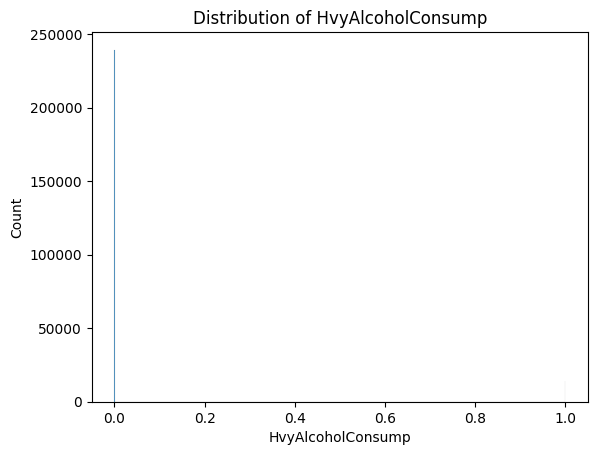

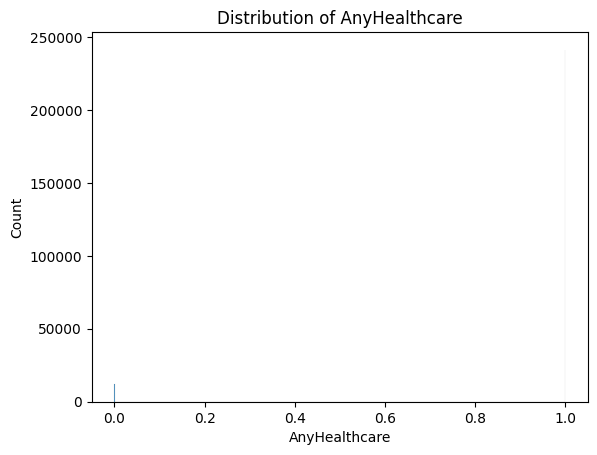

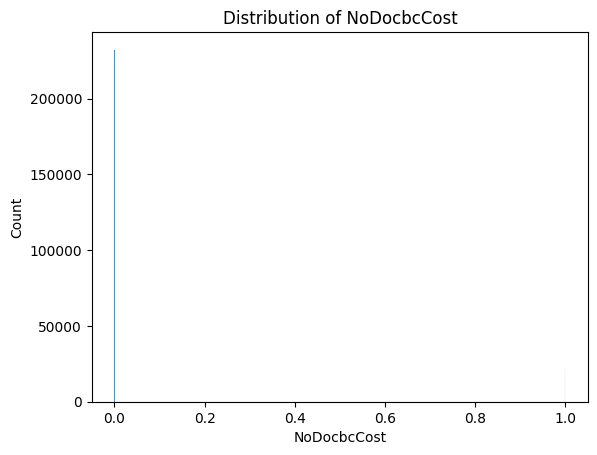

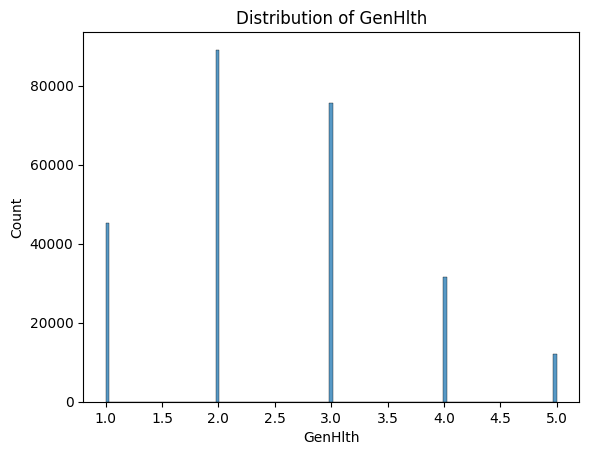

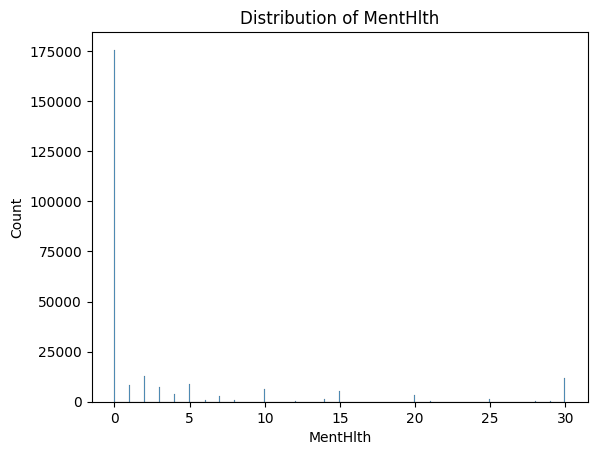

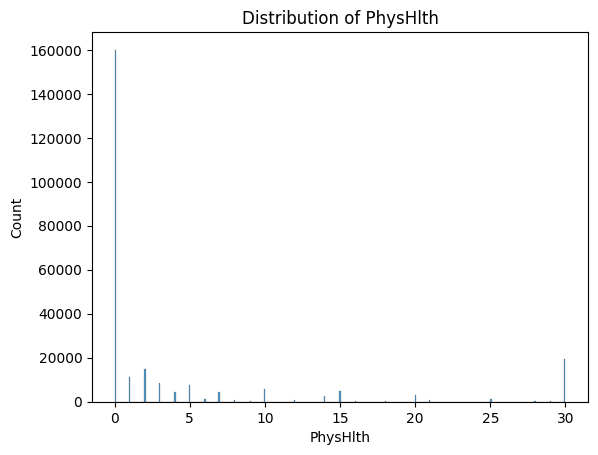

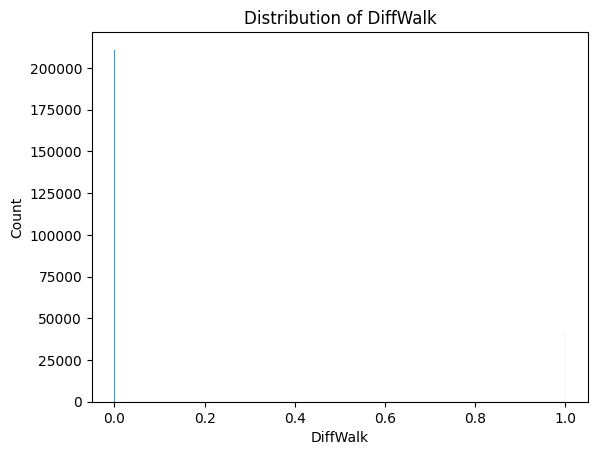

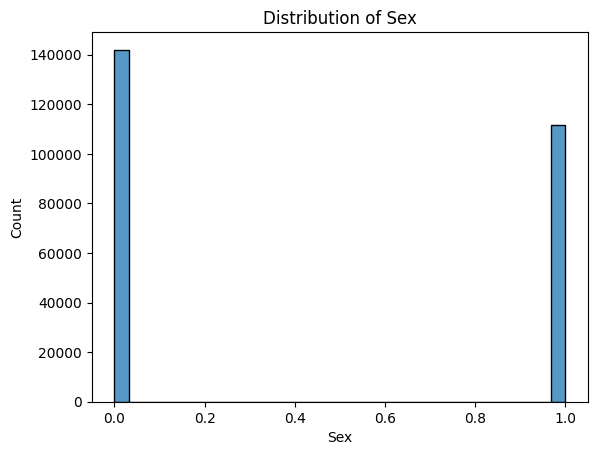

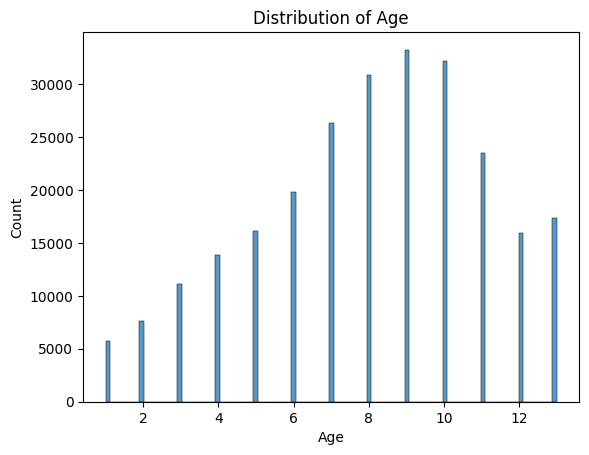

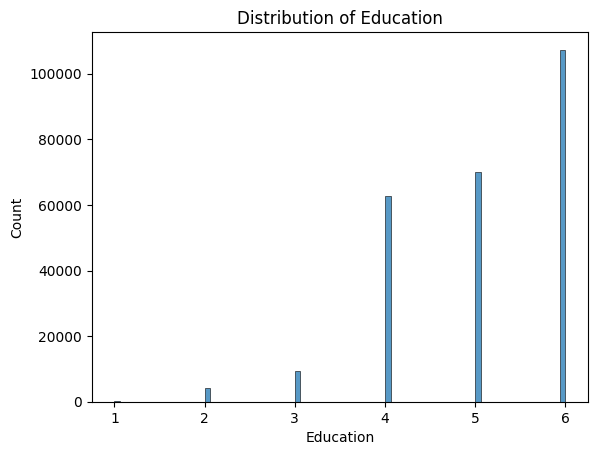

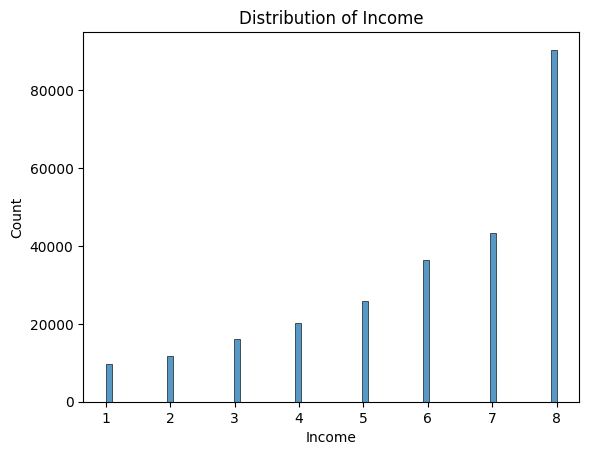

In [3]:
import seaborn as sns
from seaborn import histplot
feature_columns = diabetes_file.columns.drop('Diabetes_binary')
for col in feature_columns:
    sns.histplot(data=diabetes_file,x=col)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()

##### Feature Distribution - Joint

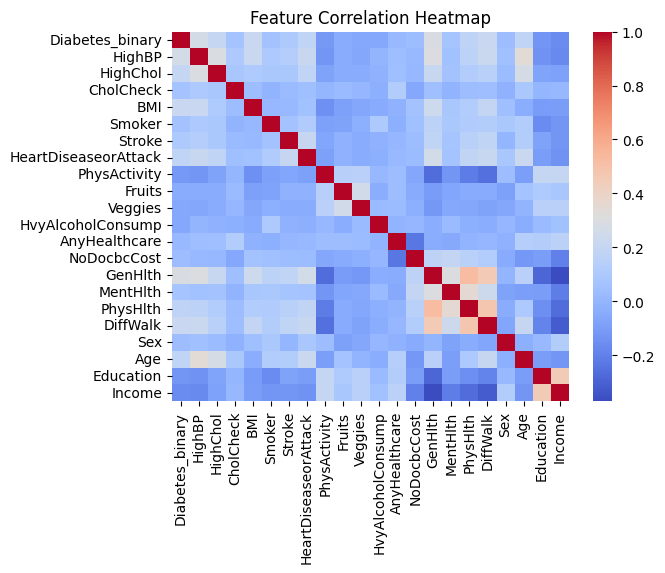

In [4]:
sns.heatmap(
    diabetes_file.corr(),
    cmap="coolwarm",
)
plt.title("Feature Correlation Heatmap")
plt.show()

In [5]:
corr = diabetes_file.corr()
pairs = (
    corr.where((corr > 0.0) & (corr != 1))
    .stack()
    .reset_index()
)

pairs.columns = ['Feature 1', 'Feature 2', 'Correlation']
pairs['sorted_pair'] = pairs.apply(
    lambda x: tuple(sorted([x['Feature 1'], x['Feature 2']])),
    axis=1
)
pairs = pairs.drop_duplicates('sorted_pair').drop('sorted_pair',axis=1)

pairs = pairs.sort_values(by='Correlation', ascending=False)
pairs = pairs[
    (pairs['Feature 1'] == 'Diabetes_binary') |
    (pairs['Feature 2'] == 'Diabetes_binary')
]
print('Strongest Positive Correlation With Diabetes_binary')
print(pairs.head(10))

Strongest Positive Correlation With Diabetes_binary
          Feature 1             Feature 2  Correlation
9   Diabetes_binary               GenHlth     0.293569
0   Diabetes_binary                HighBP     0.263129
12  Diabetes_binary              DiffWalk     0.218344
3   Diabetes_binary                   BMI     0.216843
1   Diabetes_binary              HighChol     0.200276
14  Diabetes_binary                   Age     0.177442
6   Diabetes_binary  HeartDiseaseorAttack     0.177282
11  Diabetes_binary              PhysHlth     0.171337
5   Diabetes_binary                Stroke     0.105816
10  Diabetes_binary              MentHlth     0.069315


In [6]:
negative_pairs = (
    corr.where((corr < 0))
    .stack()
    .reset_index()
)

negative_pairs.columns = ['Feature 1', 'Feature 2', 'Correlation']
negative_pairs['sorted_pair'] = negative_pairs.apply(
    lambda x: tuple(sorted([x['Feature 1'], x['Feature 2']])),
    axis=1
)
negative_pairs = negative_pairs.drop_duplicates('sorted_pair').drop('sorted_pair',axis=1)
negative_pairs = negative_pairs.sort_values(by='Correlation', ascending=True)
negative_pairs = negative_pairs[
    (negative_pairs['Feature 1'] == 'Diabetes_binary') |
    (negative_pairs['Feature 2'] == 'Diabetes_binary')
]
print('Strongest Negative Correlation With Diabetes_binary')
print(negative_pairs.head(10))

Strongest Negative Correlation With Diabetes_binary
         Feature 1          Feature 2  Correlation
5  Diabetes_binary             Income    -0.163919
4  Diabetes_binary          Education    -0.124456
0  Diabetes_binary       PhysActivity    -0.118133
3  Diabetes_binary  HvyAlcoholConsump    -0.057056
2  Diabetes_binary            Veggies    -0.056584
1  Diabetes_binary             Fruits    -0.040779


##### Observations on Features Distribution

###### Class:

The dataset shows that several health-related factors are associated with diabetes risk, while others have weak or unclear relationships. High blood pressure (HighBP) and high cholesterol (HighChol) both show noticeable associations with diabetes, with individuals in these groups having roughly a 41% likelihood of diabetes. Smoking (Smoker) follows a similar pattern, suggesting lifestyle-related conditions may contribute to increased diabetes risk. Fruit consumption (Fruits) displayed one of the stronger trends, with approximately 64% of individuals in that category associated with diabetes outcomes.

On the other hand, variables such as stroke (Stroke), heart disease or attack (HeartDiseaseorAttack), heavy alcohol consumption (HvyAlcoholConsumption), difficulty walking (DiffWalk), and inability to see a doctor because of cost (NoDocbcCost) showed relatively weak relationships with diabetes in this sample. Features like BMI, general health, mental health, age, education, and income had broad distributions, making it difficult to identify direct patterns from visual inspection alone.

Overall, the analysis suggests that cardiovascular and lifestyle-related factors — especially high blood pressure, high cholesterol, and smoking — appear to have the strongest observable relationship with diabetes, while several demographic and healthcare-access variables show limited direct correlation in the dataset.

###### Joint:

The correlation analysis shows that the variables most positively associated with Diabetes_binary are GenHlth (0.29), HighBP (0.26), DiffWalk (0.22), and BMI (0.22). This suggests that poorer general health, high blood pressure, difficulty walking, and higher body mass index are linked with a greater likelihood of diabetes. HighChol, Age, and HeartDiseaseorAttack also show moderate positive relationships with diabetes.

On the other hand, the strongest negative correlations with Diabetes_binary are Income (-0.16), Education (-0.12), and PhysActivity (-0.12). This indicates that higher income, higher education levels, and increased physical activity are associated with a lower likelihood of diabetes. Variables such as fruit and vegetable consumption and heavy alcohol consumption showed only weak negative relationships.

Overall, health condition variables and lifestyle-related factors appear to have the strongest relationships with diabetes, while socioeconomic factors such as income and education show moderate inverse relationships.

##### PCA - Top Two Principal Components

<Figure size 640x480 with 0 Axes>

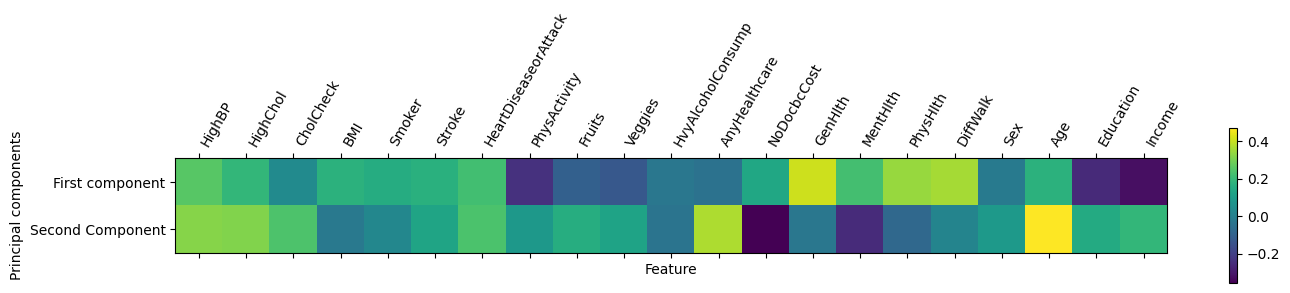

In [7]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline


X = diabetes_file.drop('Diabetes_binary', axis=1)
pca_scaled = make_pipeline(StandardScaler(), PCA(n_components=2))
X_pca_scaled = pca_scaled.fit_transform(X)

components = pca_scaled.named_steps['pca'].components_
plt.figure()
plt.matshow(components, cmap='viridis')
plt.yticks([0,1], ["First component", "Second Component"])
plt.colorbar()
plt.xticks(range(len(X.columns)), X.columns, rotation=60, ha='left')
plt.xlabel("Feature")
plt.ylabel("Principal components")
plt.show()

##### PCA - Variance

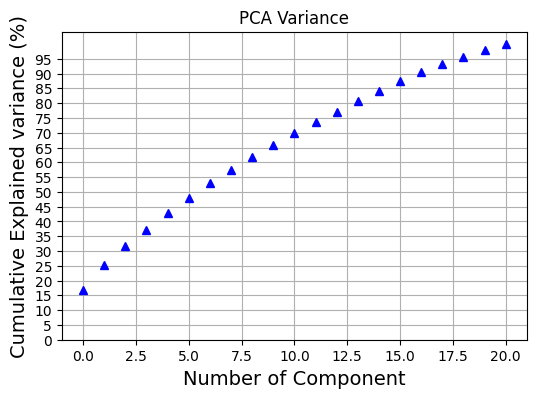

In [8]:
import numpy as np

pca_scaled = make_pipeline(StandardScaler(), PCA())
pca_scaled.fit(diabetes_file.drop('Diabetes_binary',axis=1))
pca = pca_scaled.named_steps['pca']

plt.figure(figsize=(6,4))
plt.plot(np.cumsum(pca.explained_variance_ratio_*100), 'b^')
plt.xlabel("Number of Component", fontsize = 14)
plt.ylabel("Cumulative Explained variance (%)", fontsize = 14)
plt.title("PCA Variance")
plt.yticks((np.arange(0, 100, step=5)))
plt.grid()
plt.show()

##### Observations on PCA

##### Top Two Principal Components Analysis
The first principal component (PC1) is the direction that captures the maximum variance in the dataset and represents the strongest overall pattern, while the second principal component (PC2) captures the next highest amount of variance. In the diabetes dataset, PC1 is primarily driven by general health status (GenHlth), indicating that overall health explains the largest variation among individuals, while PC2 is strongly influenced by age, reflecting a secondary demographic pattern; meanwhile, features such as income and NoDocbcCost contribute weakly to these main directions of variation, showing they have less influence on the overall structure captured by PCA.

##### Variance
The cumulative explained variance analysis shows how much of the dataset’s total information is retained as additional principal components are included. The results indicate that variance is distributed across many components, meaning that no small subset of features captures most of the structure in the data. As more components are added, the cumulative explained variance increases steadily until it reaches around 95%, which requires a relatively large number of components. A 95% variance threshold was selected in this case to prioritize information retention and model accuracy over aggressive dimensionality reduction. Although this approach results in reduced compression and a more complex representation of the data, it ensures that nearly all meaningful variation in the dataset is preserved, which is particularly important for maintaining performance in downstream analysis or predictive modeling.

#### Question 1-2:
Use different clustering algorithms to cluster the data: K-Means, DBSCAN, Agglomerative clustering, Gaussian Mixture. For each algorithm, tune the parameters for a reasonable outcome, then document your tuning procedure.
|
Pay attention to the sizes of the clusters created. Inspect the outcome, discuss any resulting clusters are meaningful.

##### Basic Clustering

In [9]:
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.mixture import GaussianMixture

In [10]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=4, random_state=42, n_init='auto').fit(X_scaled)
dbscan = DBSCAN(eps=0.5, min_samples=5,metric='euclidean').fit(X_scaled)
gm = GaussianMixture(n_components=4, covariance_type='full', random_state=42).fit(X_scaled)

In [11]:
#AggCluster is shockingly inefficient. I needed to resample or get 240 GB of Memory
#I chose to resample
from sklearn.utils import resample
X_sample = resample(X_scaled, replace=False, n_samples=5000,random_state=42)
aggcluster = AgglomerativeClustering(n_clusters=4, linkage='ward').fit(X_sample)

In [12]:
#In total they will take time, like 30 minutes
from sklearn.metrics import silhouette_score
sil = silhouette_score(X_scaled, kmeans.labels_)
print("KMeans Silhouette:", sil)

KMeans Silhouette: 0.12021330812845646


In [13]:
agg_labels = aggcluster.fit_predict(X_sample)
sil = silhouette_score(X_sample, agg_labels)
print("Agglomerative Clustering Silhouette:", sil)

Agglomerative Clustering Silhouette: 0.17833646460962674


In [14]:
gm_labels = gm.predict(X_scaled)
sil = silhouette_score(X_scaled, gm_labels)
print("Gaussian Mixture Silhouette:", sil)

Gaussian Mixture Silhouette: 0.1342378912785961


In [15]:
db_labels = dbscan.labels_
sil = silhouette_score(X_scaled, db_labels)
print("DBSCAN Silhouette:", sil)

DBSCAN Silhouette: -0.3315779457104667


Clustering algorithms (KMeans, DBSCAN, Agglomerative Clustering, and Gaussian Mixture Models) were first applied to the standardized dataset without dimensionality reduction. Performance was evaluated using silhouette score. The initial results showed generally low silhouette scores across all methods, suggesting weak separability in the feature space under standard clustering assumptions. Based on these baseline results, subsequent analysis focused on hyperparameter tuning within each clustering algorithm to assess whether model-specific parameter adjustments could improve cluster quality. DBSCAN did not identify stable density-based clusters in this dataset, suggesting weak density separation in the feature space.

##### Hyperparameter Tuning

In [16]:
#Kmeans Hyperparameter Tuning
list_n_clusters = [5,4,3,2]
for i,custom_n_cluster in enumerate(list_n_clusters):
    kmeans = KMeans(n_clusters=custom_n_cluster, random_state=42, n_init='auto').fit(X_scaled)
    sil = silhouette_score(X_scaled, kmeans.labels_)
    print(f"KMeans Silhouette {i}:", sil)

KMeans Silhouette 0: 0.0868222308244142
KMeans Silhouette 1: 0.12021330812845646
KMeans Silhouette 2: 0.20286606305960753
KMeans Silhouette 3: 0.2661916209671445


Initially, hyperparameter tuning was performed by varying the number of clusters in the range [4, 5, 6, 7]. However, this configuration did not lead to an improvement in clustering performance as measured by the silhouette score. To further investigate the effect of smaller cluster granularities, the range was subsequently adjusted to [4, 3, 2, 1]. It performed better.

In [17]:
list_agg_hyp = [2,3,4,5]
for i,agg_hyp in enumerate(list_agg_hyp):
    aggcluster = AgglomerativeClustering(n_clusters=agg_hyp, linkage='ward')
    agg_labels = aggcluster.fit_predict(X_sample)
    sil = silhouette_score(X_sample, agg_labels)
    print(f"Agglomerative Clustering Silhouette {i+1}:", sil)

Agglomerative Clustering Silhouette 1: 0.16457692426042794
Agglomerative Clustering Silhouette 2: 0.1752644328309453
Agglomerative Clustering Silhouette 3: 0.17833646460962674
Agglomerative Clustering Silhouette 4: 0.17958093499395128


Agglomerative Clustering was the simplest of the algorithms to tune, as performance improved with an increasing number of clusters in the initial experiments. Since this trend was already consistent in the initial setup, no further adjustments to the hyperparameter search range were required.

In [18]:
list_db_hyp = [2,3,4,5]
for i, db_hyp in enumerate(list_db_hyp):
    dbscan = DBSCAN(eps=0.5, min_samples=db_hyp,metric='euclidean').fit(X_scaled)
    db_labels = dbscan.labels_
    sil = silhouette_score(X_scaled, db_labels)
    print(f"DBSCAN Silhouette {i+1}:", sil)


DBSCAN Silhouette 1: -0.3655431170054029
DBSCAN Silhouette 2: -0.35927779671213234
DBSCAN Silhouette 3: -0.34585514033166564
DBSCAN Silhouette 4: -0.3315779457104667


DBSCAN initially performed the worst among the clustering algorithms, producing the only negative silhouette scores. Increasing the min_samples parameter led to slight improvements in cluster structure; however, performance remained negative overall. This suggests that DBSCAN may not be well-suited to the underlying structure of the dataset, potentially due to the absence of well-defined density-separated clusters. It also highlights a limitation of using silhouette score as an evaluation metric for density-based clustering methods, where noise points and irregular cluster shapes can distort interpretability.

In [19]:
list_gm_hyp = [2, 3, 4, 5]
for i,gm_hyp in enumerate(list_gm_hyp):
    gm = GaussianMixture(n_components=gm_hyp, covariance_type='full', random_state=42).fit(X_scaled)
    gm_labels = gm.predict(X_scaled)
    sil = silhouette_score(X_scaled, gm_labels)
    print(f"Gaussian Mixture Silhouette {i+1}:", sil)

Gaussian Mixture Silhouette 1: 0.26618121517219784
Gaussian Mixture Silhouette 2: 0.19395647237975283
Gaussian Mixture Silhouette 3: 0.1342378912785961
Gaussian Mixture Silhouette 4: 0.13288932053200045


Gaussian Mixture Models showed decreasing silhouette scores as the number of components increased. The best performance occurred with the simplest configuration, while additional components reduced cluster separation and produced more overlap between clusters. This suggests that the dataset does not naturally form multiple well-separated Gaussian-distributed groups.

##### Final Analysis
These results suggest that the dataset contains only weak natural clustering structure overall, but some algorithms were still able to identify moderately separated groupings better than others. KMeans and Gaussian Mixture Models achieved the highest silhouette scores when using fewer clusters or components, with both reaching approximately 0.266. This indicates that broader, simpler cluster structures fit the data better than highly segmented solutions, and that increasing the number of clusters generally reduced separation quality by creating more overlap between groups.

Agglomerative Clustering showed steady but relatively modest improvements as the number of clusters increased, reaching a maximum silhouette score of approximately 0.180. This suggests that hierarchical relationships may exist within the data, but the resulting clusters remain only weakly separated. The gradual increase in silhouette score also indicates that Agglomerative Clustering produced more stable behavior across different cluster counts compared to the other methods.

DBSCAN consistently produced negative silhouette scores, even after tuning min_samples, indicating poor cluster separation and substantial overlap between assigned groups. This suggests that the dataset does not contain strong density-separated regions, which are necessary for DBSCAN to perform effectively. Additionally, DBSCAN likely generated either excessive noise points or poorly defined density clusters, making the resulting clusters less meaningful for this dataset.

The overall trend across all methods indicates that simpler clustering structures produced the best outcomes. The strongest-performing configurations were those with fewer clusters or mixture components, implying that the health indicators in the dataset form broad continuous patterns rather than sharply distinct subpopulations. While some meaningful grouping behavior may exist, particularly for general health status or demographic trends, the relatively low silhouette scores overall suggest that the dataset does not naturally separate into highly distinct clusters.

#### Quesetion 1-3:
Evaluate your results with the ground truth label (0 vs. 1) using the two scores: [Normalized Mutual Information score](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.normalized_mutual_info_score.html) and [Adjust Rand Index](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.adjusted_rand_score.html ). Discuss how well did you do in previous question.

In [20]:
from sklearn.metrics import normalized_mutual_info_score, adjusted_rand_score
y = diabetes_file['Diabetes_binary']
X_sample, y_sample = resample(
    X_scaled,
    y,
    replace=False,
    n_samples=5000,
    random_state=42
)

In [21]:
kmeans = KMeans(n_clusters=2, random_state=42, n_init='auto')
k_labels = kmeans.fit_predict(X_scaled)
nmi = normalized_mutual_info_score(y, k_labels)
ari = adjusted_rand_score(y, k_labels)
print("KMeans NMI:", nmi)
print("KMeans ARI:", ari)

KMeans NMI: 0.0004643467559076253
KMeans ARI: -0.010930114062673052


In [22]:
agg = AgglomerativeClustering(n_clusters=2)
agg_labels = agg.fit_predict(X_sample)
agg = AgglomerativeClustering(n_clusters=2)
agg_labels = agg.fit_predict(X_sample)
nmi = normalized_mutual_info_score(y_sample, agg_labels)
ari = adjusted_rand_score(y_sample, agg_labels)
print("Agglomerative NMI:", nmi)
print("Agglomerative ARI:", ari)

Agglomerative NMI: 0.030925102541284295
Agglomerative ARI: 0.10173411710855393


In [23]:
dbscan = DBSCAN(eps=0.5, min_samples=db_hyp,metric='euclidean').fit(X_scaled)
db_labels = dbscan.fit_predict(X_scaled)
nmi = normalized_mutual_info_score(y, db_labels)
ari = adjusted_rand_score(y, db_labels)
print("DBSCAN Mixture NMI:", nmi)
print("DBSCAN Mixture ARI:", ari)

DBSCAN Mixture NMI: 0.02035125255944738
DBSCAN Mixture ARI: -0.08521019585073501


In [24]:
gm = GaussianMixture(n_components=2, random_state=42)
gm_labels = gm.fit_predict(X_scaled)
nmi = normalized_mutual_info_score(y, gm_labels)
ari = adjusted_rand_score(y, gm_labels)
print("Gaussian Mixture NMI:", nmi)
print("Gaussian Mixture ARI:", ari)

Gaussian Mixture NMI: 0.0004639622222465814
Gaussian Mixture ARI: -0.010925428125939489


##### Analysis:

Normalized Mutual Information (NMI) measures how much information is shared between the predicted clusters and the true labels, while Adjusted Rand Index (ARI) measures the similarity between clustering assignments and the true labels after correcting for random chance.

Overall, the clustering methods performed poorly at separating the diabetes classes. The NMI scores were all very close to 0, indicating that the generated clusters shared very little information with the actual diabetes labels. Similarly, the ARI scores were near 0 or negative for most methods, suggesting that the clustering assignments were close to random or worse than random.

Among all methods, Agglomerative clustering performed the best, achieving the highest NMI (0.03093) and ARI (0.10173). Although these scores are still relatively low, they suggest that Agglomerative clustering captured slightly more meaningful structure in the dataset compared to the other methods.

KMeans and Gaussian Mixture produced nearly identical results with extremely low NMI and negative ARI values, showing almost no agreement with the true labels. DBSCAN performed the worst overall, with a negative ARI score indicating that its clustering assignments disagreed with the actual class structure more than random clustering would.

#### Question 1-4:
Supervised learning with imbalanced data:
We are using the target variable here. Split the data in train and test set first.

Utilize Random Forest Classifier and another self-selected classification methods, compare the performance on test set, interpret the results in terms of AUC and precision.

Tune the parameters for Random Forest Classifier, does changing the `class-weight` to `balanced` help? Discuss your results and findings.

In [25]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score, roc_auc_score

train, test = train_test_split(diabetes_file, test_size=0.2, train_size=0.8, random_state=42)
rfclassifier =  RandomForestClassifier()
lregression = LogisticRegression(max_iter=1000)

y_train = train['Diabetes_binary']
X_train = train.drop('Diabetes_binary',axis=1)

y_test = test['Diabetes_binary']
X_test = test.drop('Diabetes_binary',axis=1)

rfclassifier.fit(X_train,y_train)
lregression.fit(X_train,y_train)
rf_preds = rfclassifier.predict(X_test)
lr_preds = lregression.predict(X_test)
rf_proba = rfclassifier.predict_proba(X_test)[:, 1]
lr_proba = lregression.predict_proba(X_test)[:, 1]

In [26]:
print("Random Forest Classifier Precision Score", precision_score(y_test,rf_preds))
print("Logistic Regression Precision Score", precision_score(y_test,lr_preds))
print("Random Forest Classifier AUC Score", roc_auc_score(y_test,rf_proba))
print("Logistic Regression AUC Score", roc_auc_score(y_test,lr_proba))

Random Forest Classifier Precision Score 0.49049881235154397
Logistic Regression Precision Score 0.5441729323308271
Random Forest Classifier AUC Score 0.8022222426406397
Logistic Regression AUC Score 0.8263606933697678


In [27]:
balanced_rfclassifier =  RandomForestClassifier(class_weight="balanced")
balanced_rfclassifier.fit(X_train,y_train)
preds_balanced_rfclassifier = balanced_rfclassifier.predict(X_test)
brf_proba = balanced_rfclassifier.predict_proba(X_test)[:, 1]
print("Balanced Random Forest Classifier Precision Score", precision_score(y_test,preds_balanced_rfclassifier))
print("Balanced Random Forest Classifier AUC", roc_auc_score(y_test,brf_proba))

Balanced Random Forest Classifier Precision Score 0.44755536982866695
Balanced Random Forest Classifier AUC 0.7990234522976883


##### Analysis:

Changing the class_weight="balanced" parameter did not improve model performance in this case. In fact, the results show a slight decline in both precision and AUC compared to the default Random Forest model.

Specifically, precision decreased from 0.484 to 0.453, meaning the model became slightly less precise when predicting positive diabetes cases, leading to more false positives after applying class weighting. Similarly, the AUC score decreased from 0.803 to 0.798, suggesting a small reduction in the model’s ability to distinguish between the two classes overall.

Overall, the balanced Random Forest did not provide a performance advantage on this dataset. This suggests that class imbalance may not be the primary limitation in model performance, or that adjusting class weights alone is insufficient to improve class separability. In this case, the default Random Forest model performed slightly better and remains the stronger choice based on both precision and AUC.

### Data for part 2 in this assignment (image classification using CNN):
* URL: https://www.kaggle.com/datasets/misrakahmed/vegetable-image-dataset
* On Kaggle Notebook, you can add the data set by searching the above URL
* The goal of this part is to provide a practice with CNN modeling.

In [30]:
# On Kaggle Notebook, after adding the data, you can import the data directory as follows
train_dir=("../input/vegetable-image-dataset/Vegetable Images/train")
valid_dir=("../input/vegetable-image-dataset/Vegetable Images/validation")
test_dir=("../input/vegetable-image-dataset/Vegetable Images/test")

In [31]:
# Unfortunately this part of Silas's Code Didn't Work for me so I had to rewrite it
# import kagglehub
# import shutil
# import os

# #Download to Default Location
# path = kagglehub.dataset_download("misrakahmed/vegetable-image-dataset")

# #Correct Folder
# target_dir = os.path.join(os.getcwd(),"Data")

# #Ensure it Exists
# os.makedirs(target_dir, exist_ok=True)

# #Copy Over Dataset
# shutil.copytree(path,target_dir, dirs_exist_ok=True)

# print("Dataset moved to:", target_dir)

import os
import shutil

# Change this to wherever your files are located
source_dir = r"Vegetable Images"

target_dir = os.path.join(os.getcwd(), "Data")
os.makedirs(target_dir, exist_ok=True)

shutil.copytree(source_dir, target_dir, dirs_exist_ok=True)
print("Dataset moved to:", target_dir)

Dataset moved to: C:\Users\MANYU\OneDrive\Desktop\Data Science Classes\DSCI-631 Applied Machine Learning for Data Science\Assignment\3\Data


#### Question 2-1:
Examine the dataset, what is the size of each image (how many pixels/channels in each dimension)? Are all the images have the same size?

Describe the dataset directory structure, use coding to count how many images are there in each class for train set, validation set and test set?

Visualize one sample image from each class in train set.

In [32]:
from pathlib import Path
from PIL import Image
import numpy as np
from collections import defaultdict
import matplotlib.pyplot as plt

**Dataset Structure Visualization**

In [33]:
#Slight Change - ds_root = Path("Data\Vegetable_Images")
ds_root = Path("Data")

size_map = defaultdict(list)

#Count Classes Per Split
for split in ds_root.iterdir():
    classes = 0

    if split.is_dir():
        print("SPLIT:", split.name)

        for class_folder in split.iterdir():
            classes += 1

            #Count Images Per Folder
            if class_folder.is_dir():
                images = 0
                print("   CLASS:", class_folder.name)

                for image_path in class_folder.iterdir():
                    images += 1

                    #Change Image To Array and Inpsect Shape
                    img = Image.open(image_path)
                    shape = np.array(img).shape

                    size_map[shape].append(image_path)


            print("     IMAGES IN CLASS:", images)
        print("     CLASSES IN SET:", classes)

for shape, paths in size_map.items():
    print(shape, len(paths))

SPLIT: test
   CLASS: Bean
     IMAGES IN CLASS: 200
   CLASS: Bitter_Gourd
     IMAGES IN CLASS: 200
   CLASS: Bottle_Gourd
     IMAGES IN CLASS: 200
   CLASS: Brinjal
     IMAGES IN CLASS: 200
   CLASS: Broccoli
     IMAGES IN CLASS: 200
   CLASS: Cabbage
     IMAGES IN CLASS: 200
   CLASS: Capsicum
     IMAGES IN CLASS: 200
   CLASS: Carrot
     IMAGES IN CLASS: 200
   CLASS: Cauliflower
     IMAGES IN CLASS: 200
   CLASS: Cucumber
     IMAGES IN CLASS: 200
   CLASS: Papaya
     IMAGES IN CLASS: 200
   CLASS: Potato
     IMAGES IN CLASS: 200
   CLASS: Pumpkin
     IMAGES IN CLASS: 200
   CLASS: Radish
     IMAGES IN CLASS: 200
   CLASS: Tomato
     IMAGES IN CLASS: 200
     CLASSES IN SET: 15
SPLIT: train
   CLASS: Bean
     IMAGES IN CLASS: 1000
   CLASS: Bitter_Gourd
     IMAGES IN CLASS: 1000
   CLASS: Bottle_Gourd
     IMAGES IN CLASS: 1000
   CLASS: Brinjal
     IMAGES IN CLASS: 1000
   CLASS: Broccoli
     IMAGES IN CLASS: 1000
   CLASS: Cabbage
     IMAGES IN CLASS: 1000
   C

split step...
split step...
found train...
printing image from Bean...


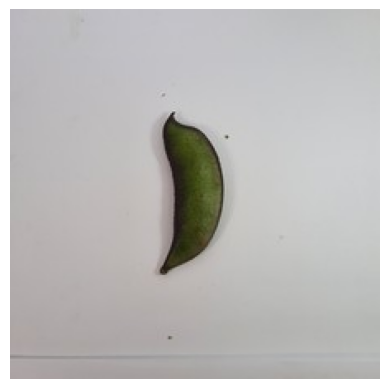

printing image from Bitter_Gourd...


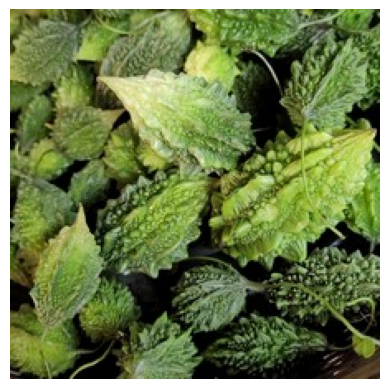

printing image from Bottle_Gourd...


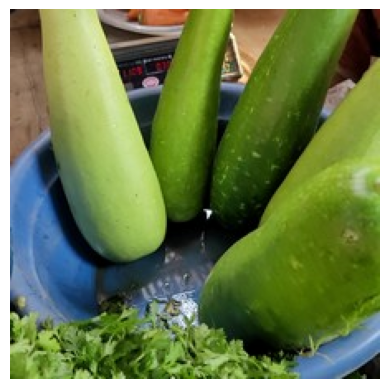

printing image from Brinjal...


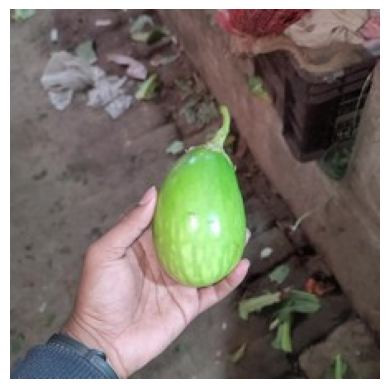

printing image from Broccoli...


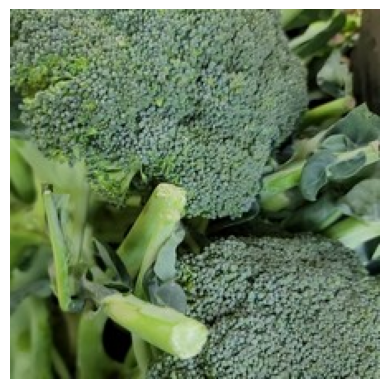

printing image from Cabbage...


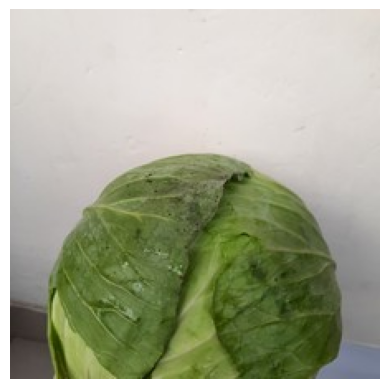

printing image from Capsicum...


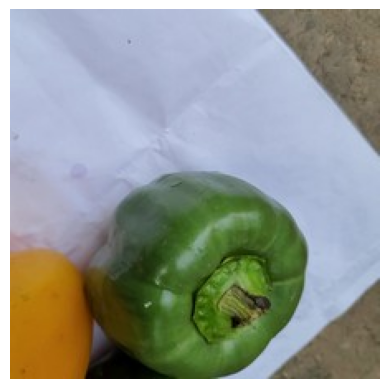

printing image from Carrot...


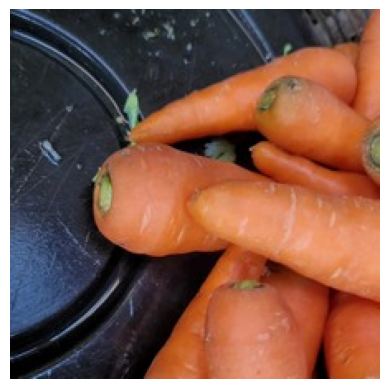

printing image from Cauliflower...


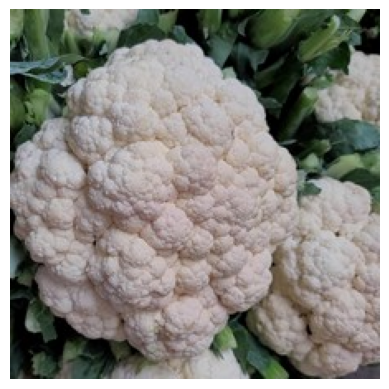

printing image from Cucumber...


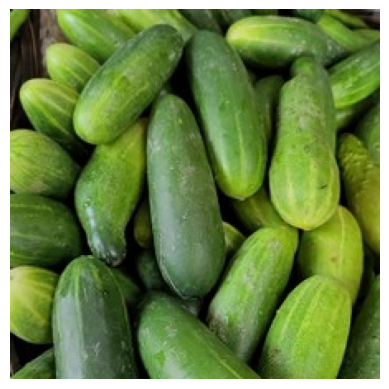

printing image from Papaya...


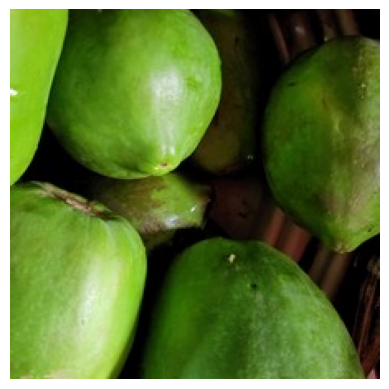

printing image from Potato...


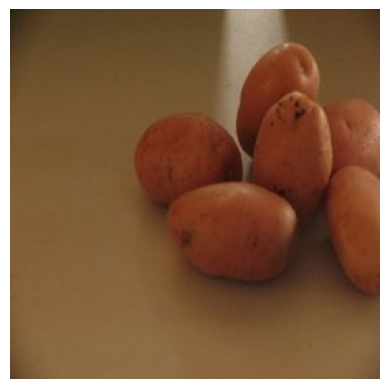

printing image from Pumpkin...


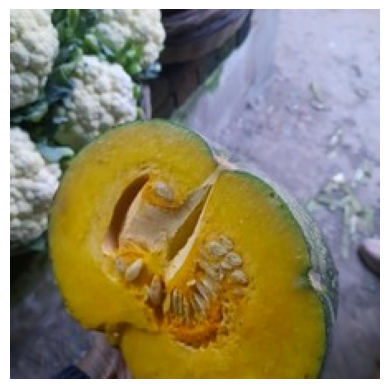

printing image from Radish...


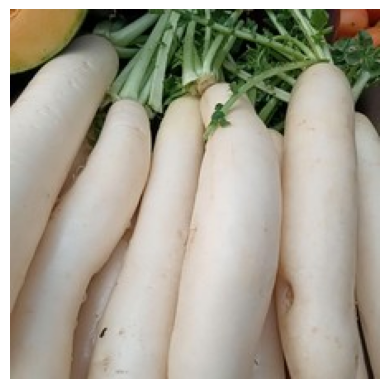

printing image from Tomato...


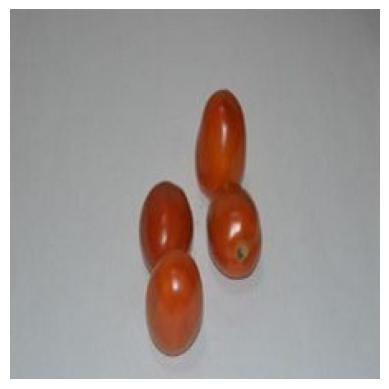

split step...


In [34]:
for split in ds_root.iterdir():
    print('split step...')
    if split.is_dir() and split.name == 'train':
        print('found train...')
        for class_folder in split.iterdir():
                print(f'printing image from {class_folder.name}...')
                for image_path in class_folder.iterdir():
                    img = Image.open(image_path)

                    #Show image
                    plt.imshow(img)
                    plt.axis('off')
                    plt.show()
                    
                    break

### Analysis

**Image Sizes:** Of the entire dataset, there were only 9 outliers which were of different dimmensions. Of these outliers only the height differs, getting as low as 187. All had the same RGB channels. The other 20991 images were square images of the dimensions (224, 224, 3). 

**Directory Structure:** There are three datasets, test, train, and validation. Each of them has all 15 of the classes. In test and validation, there are 200 images per class folder, and in the train there are 1000, reflecting the fact the training dataset is 5x the size of the test and validation datasets.

#### Question 2-2:
Build a CNN model with the following:
* Convolution layer with 32 filters of size 3x3, strides of 1, same padding and relu activation function, specify the input_shape
* MaxPooling layer with a pool size of 2
* Convolution layer with 64 filters of size 3x3, strides of 1, same padding and relu activation function
* MaxPooling layer with a pool size of 2
* Flatten layer to flatten the 3 dimensional feature volume
* Dense layer (Fully-connected) with 128 neurons and relu activation function
* Dropout layer with a dropout rate of 25%
* Dense layer (Fully-connected) with 128 neurons and relu activation function
* Final output layer with neuron number the same as class number of the dataset, and softmax activation function

For each layer, how many parameters will be trained? Show your calculation instead of just `model.summary()` only

In [39]:
import tensorflow as tf
from tensorflow.keras import layers, models

In [40]:
#Initialize Model and Set Input Shape
input_shape = (224,224,3)
class_number = 15

model = models.Sequential()

In [41]:
#1. Convolution Layer
model.add(layers.Conv2D(
    filters = 32, 
    kernel_size = (3,3),
    strides = 1,
    padding = 'same',
    activation = "relu",
    input_shape = input_shape
))

C:\Users\MANYU\miniconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [42]:
#2. Max Pooling Layer
model.add(layers.MaxPooling2D(
    pool_size = (2,2)
))

In [43]:
#3. Second Convolution Layer
model.add(layers.Conv2D(
    filters = 64,
    kernel_size = (3,3),
    strides = 1,
    padding = 'same',
    activation = "relu",
))

In [44]:
#4. Second Max Pooling Layer
model.add(layers.MaxPooling2D(
    pool_size = (2,2)
))

In [45]:
#5. Flatten Layer
model.add(layers.Flatten())

In [46]:
#6. Dense Layer
model.add(layers.Dense(
    units = 128,
    activation = 'relu'
))

In [47]:
#7. Dropout Layer with 25% Dropped
model.add(layers.Dropout(.25))

In [48]:
#8. Second Dense Layer
model.add(layers.Dense(
    units = 128,
    activation = 'relu'
))

In [49]:
#8. Final Output Layer
model.add(layers.Dense(
    units = class_number,
    activation = 'softmax'
))

### Layer Math

**Note:** For this math I will be using the shape (224, 224, 3) as the input shape. The outliers will be dropped to prevent errors during runtime.

**1. First Conv2D:** 
Input = (224, 224, 3)
Padding Maintains H x W dimensions
32 Feature Maps, Each filter slides across all channels at once:
    - Output Shape: (224, 224, 32)
Parameters = (H x W x Input_Channels + 1) * filters = (3 x 3 x 3 + 1) x 32 = 28 x 32 = 896 Parameters

**2. First Max Pooling:** 
Input = (224, 224, 32)
Pooling reduces H/2 and W/2 = (112, 112, 32)
Parameters = 0, Max Pool has no learnable weights

**3. Second Conv2D:** 
Input = (112, 112, 32)
Padding Maintains H x W dimensions
64 Feature Maps, Each filter slides across all channels at once:
    - Output Shape: (112, 112, 64)
Parameters = (filter_H x filter_W x Input_Channels + 1) * filters = (3 x 3 x 32 + 1) x 64 = 289 x 64 = 18,496 Parameters

**4. Second Max Pooling:** 
Input = (112, 112, 64)
Pooling reduces H/2 and W/2 = (56, 56, 64)
Parameters = 0, Max Pool has no learnable weights

**5. Flatten Layer:**
Input = (56, 56, 64)
Output = (56 x 56 x 64) = (200,704, )
Parameters = 0, Flatten has no learnable weights

**6. First Dense Layer**
Input = (200,704,)
Neurons = 128
Parameters = Each neuron connects to all inputs = (200,704 x 128 neuron_weights) + 128 neuron_biases = 25,690,240 Parameters
Output = (128,)

**7. Dropout Layer**
Input = (128,)
Drops 25% to be zero, shape unchanged
Output = (128,)

**8. Second Dense Layer**
Input = (128,)
Neurons = Class_count = 15
Parameters = Each neuron connects to all inputs = (128 x 10 neuron_weights) + 10 neuron_biases = 1,290 Parameters
Output = (10,)



#### Question 2-3:
Compile your CNN model with `Adam` optimizer, `categorical_crossentropy` as loss, `accuracy` as metrics, and fit with train and validation data. You can control the rest of the parameter with `.fit()` by yourself.
What is the total time for training?

Evaluate the trained model with test set, how is the performance?

What is your observation from this practice, and what you have learnt from this practice?

In [50]:
train_dir = 'Data\train'

In [51]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    "Data/train",
    image_size = (224, 224),
    batch_size = 32
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    "Data/validation",
    image_size = (224, 224),
    batch_size = 32
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    "Data/test",
    image_size = (224, 224),
    batch_size = 32
)

Found 15000 files belonging to 15 classes.
Found 3000 files belonging to 15 classes.
Found 3000 files belonging to 15 classes.


In [52]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.fit(train_ds, validation_data=val_ds)

469/469 ━━━━━━━━━━━━━━━━━━━━ 236s 500ms/step - accuracy: 0.3378 - loss: 24.5970 - val_accuracy: 0.5477 - val_loss: 1.5074


In [53]:
model.evaluate(test_ds)

94/94 ━━━━━━━━━━━━━━━━━━━━ 8s 81ms/step - accuracy: 0.5390 - loss: 1.5214


[1.521397590637207, 0.5389999747276306]

### Analysis

**Total Training Time:** The model, compiled with the Adam optimizer and categorical crossentropy took 79 seconds to train. Evaluation took only 4 seconds.

**Performance:** The model performed fairly well, with an accuracy of 56%. This means that the model was correct in its assumptions more than half the time, which is far greater than would be expected if just guessing randomly/a single option.

**Observation and Takeaways:** 
This assignment really worked to highlihgt how well a convolutional model works to decrease the computational demand of image identification while still performing with a solid accuracy. What is most impressive is to see how much the data can be distilled, passing through multiple filter and max pool layers, while still retaining enough important information to be (semi)accurately identified. I was particularly impressed by how well this worked even given the fact many of the chosen classes were very similar in color and shape. 